# 02 - Modelado y evaluación de uplift

Este notebook corre de punta a punta el pipeline que vive en `src/` (no
duplica la lógica, solo la importa) para poder **analizar los resultados de
forma interactiva**: entrenar los 3 meta-learners y el Uplift Tree, comparar
contra los baselines con AUUC/Qini, ver las curvas de Qini, correr la
validación multi-split y aplicar SHAP sobre el modelo ganador.

Si ya leíste el `README.md`, esto es la versión "ejecutable" de la sección
de Resultados: cada tabla y cada número que aparece ahí se puede reproducir
y explorar acá.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalml.metrics import plot_qini, plot_gain

from preprocessing import load_and_prepare
from models import (
    train_s_learner, train_t_learner, train_x_learner, train_uplift_tree,
    predict_uplift, predict_uplift_tree,
)
from evaluation import (
    build_random_targeting_baseline, train_response_model_baseline,
    predict_response_model_score, build_evaluation_frame, evaluate_models,
    evaluate_with_multiple_splits,
)
from interpretation import (
    compute_shap_for_winning_model, plot_shap_summary,
    get_feature_importance_ranking,
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# interpretation.py fuerza el backend "Agg" (no interactivo) al importarse,
# porque está pensado para correr como script y guardar figuras a archivo.
# Acá, en cambio, sí queremos ver los gráficos inline en el notebook, así
# que forzamos el backend interactivo de Jupyter DESPUÉS de ese import.
%matplotlib inline


Failed to import duecredit due to No module named 'duecredit'


## 1. Cargar datos y entrenar los 4 modelos

Usamos el split de referencia (`random_state=42`, el mismo del README) para
esta primera pasada. Más abajo repetimos todo con varios splits para ver
qué tan estable es el ranking.


In [2]:
(
    X_train, X_test,
    treatment_train, treatment_test,
    y_train, y_test,
    df_train, df_test,
) = load_and_prepare("../data/raw/hillstrom.csv")

print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"% tratados train/test: {treatment_train.mean():.2%} / {treatment_test.mean():.2%}")
print(f"Tasa de conversión train/test: {y_train.mean():.4%} / {y_test.mean():.4%}")


Train: 44,800 filas | Test: 19,200 filas
% tratados train/test: 66.71% / 66.71%
Tasa de conversión train/test: 0.9018% / 0.9062%


In [3]:
print("Entrenando S-Learner...")
s_learner = train_s_learner(X_train, treatment_train, y_train)

print("Entrenando T-Learner...")
t_learner = train_t_learner(X_train, treatment_train, y_train)

print("Entrenando X-Learner...")
x_learner = train_x_learner(X_train, treatment_train, y_train)

print("Entrenando Uplift Tree...")
tree = train_uplift_tree(X_train, treatment_train, y_train)

print("Entrenando baseline Response Model...")
response_model = train_response_model_baseline(X_train, y_train)

print("Listo.")


Entrenando S-Learner...


Entrenando T-Learner...


Entrenando X-Learner...


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklear

C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Entrenando Uplift Tree...


Entrenando baseline Response Model...


Listo.


## 2. Comparar los 3 meta-learners contra los 2 baselines

Armamos un único DataFrame de evaluación (`y`, `w` y una columna de score
por modelo/baseline) y calculamos AUUC y Qini para todos a la vez con
`evaluate_models`, tal como lo hace `src/evaluation.py`.


In [4]:
scores = {
    "S-Learner": predict_uplift(s_learner, X_test),
    "T-Learner": predict_uplift(t_learner, X_test),
    "X-Learner": predict_uplift(x_learner, X_test),
    "Uplift Tree": predict_uplift_tree(tree, X_test),
    "Response Model (baseline)": predict_response_model_score(response_model, X_test),
    "Random Targeting (baseline)": build_random_targeting_baseline(len(y_test)),
}

eval_df = build_evaluation_frame(y_test, treatment_test, scores)
resumen = evaluate_models(eval_df)
resumen


,AUUC,Qini
X-Learner,0.6104,0.1095
T-Learner,0.5791,0.0796
Uplift Tree,0.5291,0.0301
S-Learner,0.5253,0.0249
Response Model (baseline),0.4876,-0.0126
Random Targeting (baseline),0.4658,-0.0350


Esta tabla es la misma que aparece en el README bajo *"Resultado sobre el
split de referencia"*. El X-Learner encabeza en este split puntual — pero
ya sabemos (sección 4) que eso no es representativo por sí solo.

## 3. Curvas de Qini y de Ganancia acumulada

Las curvas muestran, para cada modelo, cuánta ganancia incremental se
acumula a medida que se targetea a una fracción creciente de la población
(ordenada de mayor a menor uplift predicho). Una curva por encima de la
diagonal ("Random") indica que el modelo agrega valor sobre targetear al
azar; cuanto más área bajo la curva y por encima de la diagonal, mejor.


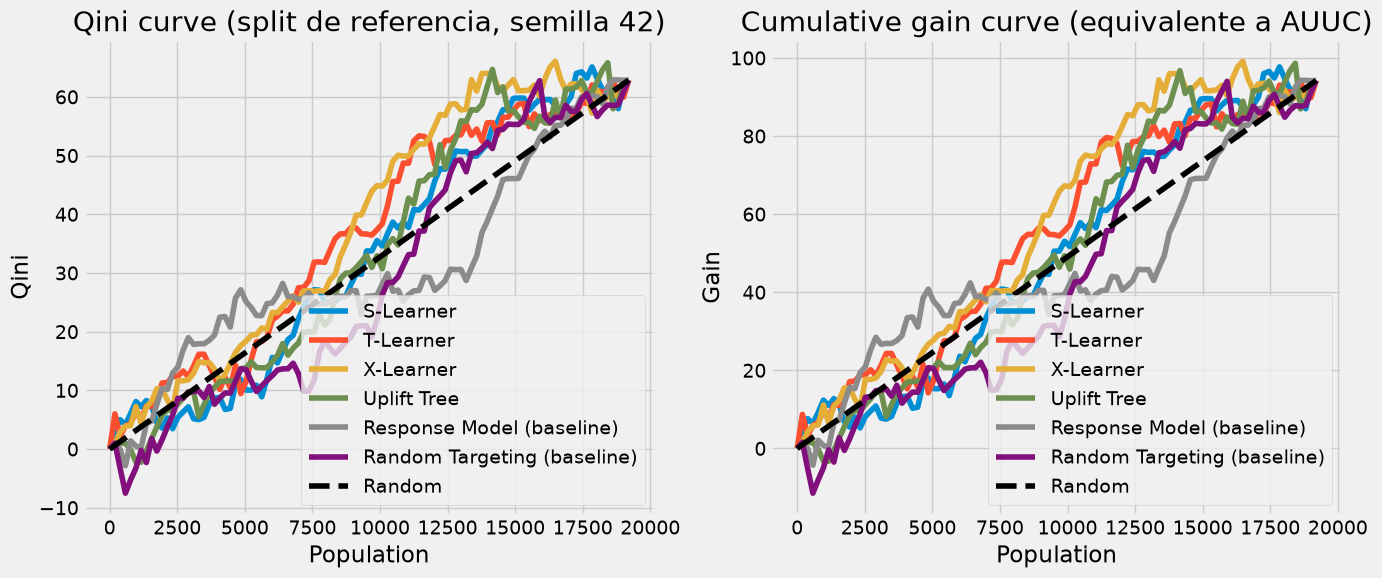

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_qini(eval_df, outcome_col="y", treatment_col="w", ax=axes[0])
axes[0].set_title("Qini curve (split de referencia, semilla 42)")

plot_gain(eval_df, outcome_col="y", treatment_col="w", ax=axes[1])
axes[1].set_title("Cumulative gain curve (equivalente a AUUC)")

plt.tight_layout()
plt.show()


## 4. ¿El ranking se sostiene con otros splits?

Un solo test set tiene apenas ~174 conversiones (0.9% de 19,200 clientes),
así que el Qini/AUUC de la sección 2 puede ser optimista o pesimista solo
por azar. Repetimos el pipeline completo (split → entrenar 4 modelos +
2 baselines → evaluar) con varias semillas distintas usando
`evaluate_with_multiple_splits`, y miramos la media y el desvío estándar de
cada métrica entre splits.

Nota sobre `n_splits`: con solo 4 splits el "ganador" cambiaba según qué
semillas se usaran (llegamos a ver a Random Targeting encabezar la tabla
en una tanda de 4 splits distinta a la de abajo). Por eso acá usamos
`n_splits=10` — todavía no es un intervalo de confianza riguroso, pero ya
da una media mucho más estable que con 4 splits. Esta celda tarda varios
minutos porque entrena 5 modelos × 10 splits = 50 modelos.


In [6]:
def entrenar_y_evaluar_un_split(df_completo, random_state):
    """Reproduce, para UN split con la semilla dada, todo el flujo de la
    sección 2. Es la función que `evaluate_with_multiple_splits` llama una
    vez por semilla; recibe el DataFrame crudo (ya con treatment/outcome
    armados) y arma su propio split, sus propios modelos y su propia tabla.
    """
    from preprocessing import (
        stratified_train_test_split, build_feature_matrix,
        TREATMENT_COL, OUTCOME_COL,
    )

    df_tr, df_te = stratified_train_test_split(
        df_completo, test_size=0.3, random_state=random_state
    )
    X_tr = build_feature_matrix(df_tr)
    X_te = build_feature_matrix(df_te)
    w_tr = df_tr[TREATMENT_COL].to_numpy()
    w_te = df_te[TREATMENT_COL].to_numpy()
    y_tr = df_tr[OUTCOME_COL].to_numpy()
    y_te = df_te[OUTCOME_COL].to_numpy()

    s = train_s_learner(X_tr, w_tr, y_tr)
    t = train_t_learner(X_tr, w_tr, y_tr)
    x = train_x_learner(X_tr, w_tr, y_tr)
    ut = train_uplift_tree(X_tr, w_tr, y_tr)
    rm = train_response_model_baseline(X_tr, y_tr)

    scores_split = {
        "S-Learner": predict_uplift(s, X_te),
        "T-Learner": predict_uplift(t, X_te),
        "X-Learner": predict_uplift(x, X_te),
        "Uplift Tree": predict_uplift_tree(ut, X_te),
        "Response Model (baseline)": predict_response_model_score(rm, X_te),
        "Random Targeting (baseline)": build_random_targeting_baseline(
            len(y_te), random_state=random_state
        ),
    }
    eval_df_split = build_evaluation_frame(y_te, w_te, scores_split)
    return evaluate_models(eval_df_split)


from preprocessing import load_raw_data, build_treatment_and_outcome

df_completo = build_treatment_and_outcome(load_raw_data("../data/raw/hillstrom.csv"))

resumen_multi_split = evaluate_with_multiple_splits(
    entrenar_y_evaluar_un_split, df_completo, n_splits=10
)
resumen_multi_split


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklear

C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\josue\claude\uplift-retention-model\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


AUUC           Qini       
                              mean    std    mean    std
modelo                                                  
X-Learner                   0.5436 0.0867  0.0442 0.0873
Uplift Tree                 0.5416 0.1008  0.0417 0.1016
T-Learner                   0.5246 0.0735  0.0258 0.0751
Random Targeting (baseline) 0.5200 0.0801  0.0195 0.0807
Response Model (baseline)   0.5144 0.0719  0.0147 0.0725
S-Learner                   0.4944 0.0713 -0.0044 0.0719

**Lectura de esta tabla:** el desvío estándar de Qini/AUUC entre splits
(~0.08-0.10) sigue siendo grande en relación a la media (~0.04 para el
X-Learner) — con tan pocas conversiones en cada test set, un split
individual puede darte casi cualquier ranking. Pero promediando 10 splits
en vez de 4 el resultado ya es bastante más estable: el X-Learner encabeza
tanto AUUC como Qini en promedio, seguido de cerca por el Uplift Tree, y
el S-Learner queda último (su Qini promedio es directamente negativo). El
X-Learner tiene a favor, además, el argumento estructural de estar
diseñado para grupos desbalanceados como los de Hillstrom — la
recomendación final en el README se apoya en ambos puntos, con la
salvedad explícita de que el margen sigue sin ser enorme frente al ruido.

## 5. Interpretabilidad: reglas del Uplift Tree

Antes de ir a SHAP (que explica el X-Learner "por dentro"), miramos las
reglas explícitas que aprendió el Uplift Tree — son directamente legibles
para alguien de negocio, sin necesitar explicar qué es un SHAP value.


In [7]:
from causalml.inference.tree import uplift_tree_string

print(uplift_tree_string(tree.fitted_uplift_tree, list(X_train.columns)))


newbie >= 0.1?
yes -> history >= 50.262?
		yes -> womens >= 0.1?
				yes -> [np.float64(0.006200177147918512), np.float64(0.012805587892898719)]
				no  -> [np.float64(0.0019584802193497847), np.float64(0.008585365853658537)]
		no  -> recency >= 3.0?
				yes -> [np.float64(0.0), np.float64(0.007777322963569382)]
				no  -> [np.float64(0.003676470588235294), np.float64(0.01338432122370937)]
no  -> history >= 441.6434999999994?
		yes -> [np.float64(0.017543859649122806), np.float64(0.011583011583011582)]
		no  -> womens >= 0.1?
				yes -> [np.float64(0.0071108770081643406), np.float64(0.012025901942645698)]
				no  -> [np.float64(0.0075392038600723766), np.float64(0.009271925824593403)]
None


## 6. SHAP sobre el X-Learner: qué mueve el UPLIFT (no la conversión)

Como se explica en `src/interpretation.py`, esto NO es un SHAP normal sobre
probabilidad de compra: es SHAP sobre el `tau` (uplift) ya estimado por el
X-Learner. Una feature puede ser irrelevante para saber si alguien compra y
aun así ser justo la que distingue a los clientes "persuadibles" por el
email.


In [8]:
uplift_pred_x = predict_uplift(x_learner, X_test)

shap_values = compute_shap_for_winning_model(
    x_learner, X_test, uplift_pred_x, feature_names=list(X_test.columns)
)

ranking = get_feature_importance_ranking(shap_values, list(X_test.columns))
ranking.head(10)


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

,feature,importancia_shap_sobre_uplift
0,history,0.0030
1,recency,0.0013
2,womens,0.0010
3,channel_Phone,0.0008
4,newbie,0.0007
5,mens,0.0005
6,zip_code_Urban,0.0003
7,channel_Web,0.0002
8,zip_code_Surburban,0.0002
9,history_segment_4) $350 - $500,0.0001


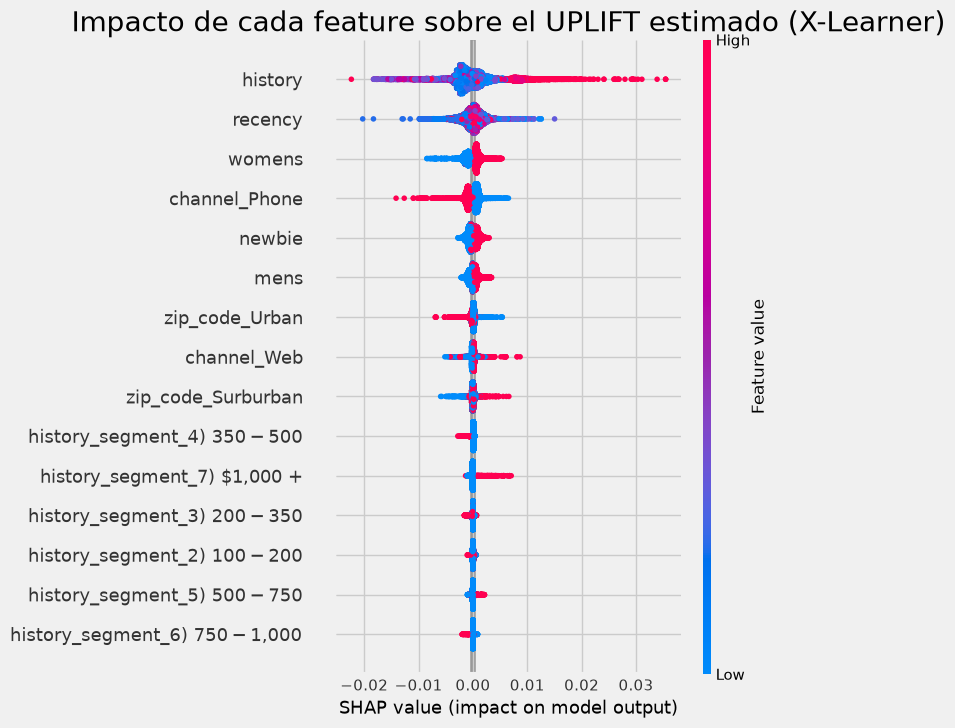

In [9]:
import shap

shap.summary_plot(shap_values, X_test, show=False)
plt.title("Impacto de cada feature sobre el UPLIFT estimado (X-Learner)")
plt.tight_layout()
plt.show()


## Conclusión

Este notebook reproduce, de forma interactiva y auditable, cada número y
cada gráfico que respalda la tabla comparativa y la recomendación del
`README.md`. Para el detalle narrativo completo (qué es uplift modeling,
por qué Qini es más confiable que AUUC acá, y la discusión completa sobre
la variabilidad entre splits) ver el README en la raíz del proyecto.
